# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
df = pd.read_csv(
    "data/cleaned_aviation_data.csv",
    low_memory=False,
)

df.shape

(17950, 34)

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [5]:
df["Aircraft.Size"] = np.where(
    df["Total.Passengers"] >= 20,
    "Large Passenger Aircraft",
    "Small Aircraft",
)

df["Aircraft.Size"].value_counts()

Aircraft.Size
Small Aircraft              17072
Large Passenger Aircraft      878
Name: count, dtype: int64

I separated aircraft into small aircraft and large passenger aircraft using a threshold of 20 estimated passengers. Aircraft with 20 or more estimated passengers were labeled as larger passenger aircraft, while aircraft below that threshold were labeled as smaller aircraft. This allows the analysis to provide separate recommendations for the two aircraft groups requested by the client.

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [14]:
make_injury_summary = (
    df.groupby(["Aircraft.Size", "Make"])
    .agg(
        accident_count=("Make", "size"),
        mean_fatal_serious_injury_fraction=(
            "Fatal.Serious.Injury.Fraction",
            "mean",
        ),
    )
    .reset_index()
)

min_records_per_group = 20

make_injury_summary_filtered = make_injury_summary[
    make_injury_summary["accident_count"] >= min_records_per_group
].copy()

lowest_15_makes_by_size = (
    make_injury_summary_filtered
    .sort_values(
        ["Aircraft.Size", "mean_fatal_serious_injury_fraction"],
        ascending=[True, True],
    )
    .groupby("Aircraft.Size")
    .head(15)
    .copy()
)

lowest_15_makes_by_size[
    "mean_fatal_serious_injury_percent"
] = (
    lowest_15_makes_by_size["mean_fatal_serious_injury_fraction"] * 100
)

lowest_15_makes_by_size

,Aircraft.Size,Make,accident_count,mean_fatal_serious_injury_fraction,mean_fatal_serious_injury_percent
8,Large Passenger Aircraft,MCDONNELL DOUGLAS,53,0.007827,0.782706
3,Large Passenger Aircraft,BOMBARDIER,65,0.039560,3.955964
2,Large Passenger Aircraft,BOEING,547,0.056771,5.677074
6,Large Passenger Aircraft,EMBRAER,78,0.065274,6.527402
0,Large Passenger Aircraft,AIRBUS,118,0.086249,8.624853
33,Small Aircraft,MCDONNELL DOUGLAS,55,0.094048,9.404762
21,Small Aircraft,BOMBARDIER,50,0.102308,10.230769
20,Small Aircraft,BOEING,714,0.141973,14.197270
32,Small Aircraft,MAULE,215,0.164806,16.480620
16,Small Aircraft,AVIAT,146,0.191781,19.178082


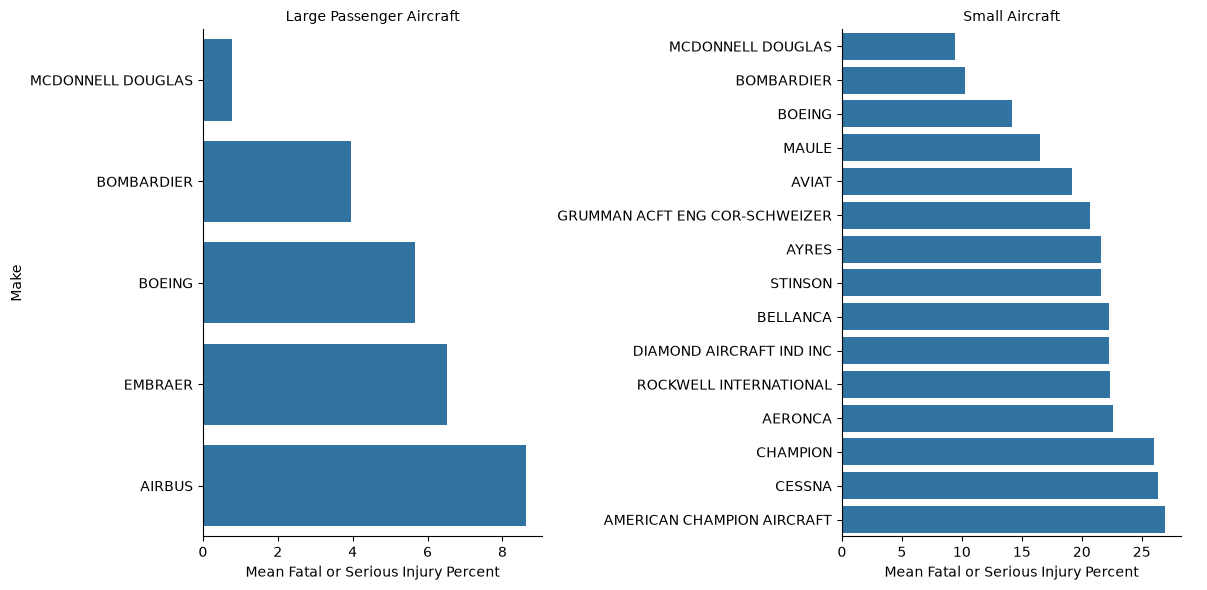

In [15]:
g = sns.catplot(
    data=lowest_15_makes_by_size,
    x="mean_fatal_serious_injury_percent",
    y="Make",
    col="Aircraft.Size",
    kind="bar",
    sharex=False,
    sharey=False,
    height=6,
    aspect=1,
)

g.set_axis_labels(
    "Mean Fatal or Serious Injury Percent",
    "Make",
)

g.set_titles("{col_name}")

plt.show()

I grouped the data by aircraft size and make, then calculated the mean fatal or serious injury fraction for each group. I used a minimum of 20 accident records per make and size group so the comparison would not rely on very small samples.

Although the prompt asks for 15 makes in each group, only 5 larger passenger aircraft makes met the 20 record threshold. I kept this threshold because including lower count makes would make the larger aircraft chart less reliable and could overstate risk based on too few accidents.

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.